In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from textwrap import fill

#load the Lookup data/lookup_oa2022_lsoa11_EW.csv
oa_lsoa = pd.read_csv('../data/geofiles/lookup_oa2022_lsoa11_EW.csv')
#rename columns

oa_lsoa.set_index('OA21CD',inplace=True)

oa_msoa = pd.read_csv('../data/geofiles/Output_Area_to_Lower_layer_Super_Output_Area_to_Middle_layer_Super_Output_Area_to_Local_Authority_District_(December_2021)_Lookup_in_England_and_Wales_v3.csv')[["OA21CD","MSOA21CD"]].set_index('OA21CD')



imd = pd.read_csv('../data/geofiles/uk_imd2019.csv')
imd = imd[["LSOA","SOA_decile"]]
imd.columns = ['LSOA11CD','IMD']

#density 
density = pd.read_csv('../data/census_data/eng_raw_csvs/ts006.csv')
#rename ts006001 to density
density.columns = ['OA21CD','Density']
#calculate deciles
density['Density_decile'] = pd.qcut(density['Density'],10,labels=False)
#reverse deciles
density['Density_decile'] = 10 - density['Density_decile']
#drop density
density.drop('Density',axis=1,inplace=True)
#set index as OA
density.set_index('OA21CD',inplace=True)


urban_rural = pd.read_csv('../data/geofiles/Rural_Urban_Classification_(2021)_of_Output_Areas_in_EW.csv').set_index('OA21CD')

/tmp/ipykernel_340942/2172078639.py:14: DtypeWarning: Columns (3,6,9) have mixed types. Specify dtype option on import or set low_memory=False.
  oa_msoa = pd.read_csv('../data/geofiles/Output_Area_to_Lower_layer_Super_Output_Area_to_Middle_layer_Super_Output_Area_to_Local_Authority_District_(December_2021)_Lookup_in_England_and_Wales_v3.csv')[["OA21CD","MSOA21CD"]].set_index('OA21CD')


In [136]:

# Load the cleaned data
cleaned_data_path = "../data/census_data/engcensus_cleaned_scaled.parquet"
data = pd.read_parquet(cleaned_data_path)
# Ensure OA is a column, not just an index
data = data.reset_index()

reco_err = pd.DataFrame()
pca_reco_err = pd.DataFrame()

bottleneck_sizes = [128]
for bottleneck in bottleneck_sizes:
    print(f"Processing bottleneck: {bottleneck}")
    # Load reconstructed autoencoder data
    reco_path = f"../AE_outputs/engcensus/200epoch_scan_alleng_lin/census_geodemo__bottleneck_{bottleneck}_v1__reconstructed_outputs.csv"
    reco_data = pd.read_csv(reco_path, index_col=0)

    # Load PCA reconstruction data
    pca_path = f"../data/PCA_unscaled/{bottleneck}_components.csv"
    pca_reco = pd.read_csv(pca_path, index_col=0)

    # Compute reconstruction errors
    ae_err = np.abs(data.set_index("OA") - reco_data).mean(axis=1).reset_index()
    pca_err = np.abs(data.set_index("OA") - pca_reco).mean(axis=1).reset_index()

    
    # Rename columns
    ae_err = ae_err.rename(columns={0: f"reco_err_{bottleneck}"})
    pca_err = pca_err.rename(columns={0: f"pca_err_{bottleneck}"})
    # Normalize errors
    
    ae_err[f"reco_err_{bottleneck}_norm"] = ae_err[f"reco_err_{bottleneck}"] / ae_err[f"reco_err_{bottleneck}"].mean() * 100
    pca_err[f"pca_err_{bottleneck}_norm"] = pca_err[f"pca_err_{bottleneck}"] / pca_err[f"pca_err_{bottleneck}"].mean() * 100

    # Merge into final DataFrames
    if reco_err.empty:
        reco_err = ae_err
        pca_reco_err = pca_err
    else:
        reco_err = reco_err.merge(ae_err, on="OA")
        pca_reco_err = pca_reco_err.merge(pca_err, on="OA")


#rename OA to OA21CD
reco_err.rename(columns={"OA": "OA21CD"}, inplace=True)
pca_reco_err.rename(columns={"OA": "OA21CD"}, inplace=True)

Processing bottleneck: 128


In [ ]:
# Load OAC data
OAC = pd.read_csv("../data/OAC/OAC_assignment.csv")
OAC = OAC[["Geography_Code", "Supergroup8", "Group", "Subgroup"]]
OAC = OAC.rename(columns={"Geography_Code": "OA21CD"})

print("Len OAC",len(OAC))
# Load the data/OAC_cats.csv
OAC_cats = pd.read_csv("../data/OAC/OAC_cats.csv")
OAC_cats = OAC_cats[['Classification Code', 'Classification Name']]

# Make a dict out of the first 8 rows
OAC_cats_dict = OAC_cats.set_index('Classification Code')['Classification Name'].to_dict()

# Convert Supergroup8 to string before mapping
OAC['Supergroup8'] = OAC['Supergroup8'].astype(str)
OAC['Supergroup_name'] = OAC['Supergroup8'].map(OAC_cats_dict)

# Convert Group to string before mapping
OAC['Group'] = OAC['Group'].astype(str)
OAC['Group_name'] = OAC['Group'].map(OAC_cats_dict)

print("Len OAC",len(OAC))

# Merge OAC data
reco_err = reco_err.merge(OAC, on="OA21CD", how="left")
pca_reco_err = pca_reco_err.merge(OAC, on="OA21CD", how="left")

#add urban rural
reco_err = reco_err.merge(urban_rural, on="OA21CD", how="left")
pca_reco_err = pca_reco_err.merge(urban_rural, on="OA21CD", how="left")
# Add density deciles
reco_err = reco_err.merge(density, on="OA21CD", how="left")
pca_reco_err = pca_reco_err.merge(density, on="OA21CD", how="left")

print("Len reco_err after EN",len(reco_err))
# Add LSOA
reco_err = reco_err.merge(oa_lsoa, on="OA21CD", how="left")
pca_reco_err = pca_reco_err.merge(oa_lsoa, on="OA21CD", how="left")

# Add MSOA
reco_err = reco_err.merge(oa_msoa, on="OA21CD", how="left")
pca_reco_err = pca_reco_err.merge(oa_msoa, on="OA21CD", how="left")

print("Len reco_err after LSOA",len(reco_err))
#drop nans
reco_err = reco_err.dropna()
print("Len reco_err after dropna",len(reco_err))
print("len imd",len(imd))
# Add IMD
reco_err = reco_err.merge(imd, on="LSOA11CD", how="left").dropna()
pca_reco_err = pca_reco_err.merge(imd, on="LSOA11CD", how="left").dropna()

print("Len reco_err after IMD",len(reco_err))



#set IMD to INT
reco_err["IMD"] = reco_err["IMD"].astype(int)
pca_reco_err["IMD"] = pca_reco_err["IMD"].astype(int)


FileNotFoundError: [Errno 2] No such file or directory: '../data/OAC_cats.csv'

In [124]:
def prepare_grouped_data(df1, df2, group_col, bottleneck):
    """Merge two datasets and compute mean reconstruction error for each group."""
    ae_col = f"reco_err_{bottleneck}_norm"
    pca_col = f"pca_err_{bottleneck}_norm"
    
    grouped_1 = df1.groupby(group_col)[ae_col].mean().reset_index()
    grouped_2 = df2.groupby(group_col)[pca_col].mean().reset_index()
    
    grouped = grouped_1.merge(grouped_2, on=group_col)
    grouped.rename(columns={ae_col: "AE", pca_col: "PCA"}, inplace=True)
    
    grouped_melted = grouped.melt(id_vars=[group_col], var_name="Error Type", value_name="Mean Reco Error")
    return grouped, grouped_melted

def plot_bar_chart(df, x_col, y_col, hue_col, title, xlabel, ylabel, palette):
    plt.figure(figsize=(8, 5))
    sns.barplot(x=x_col, y=y_col, hue=hue_col, data=df, palette=palette)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.legend(title=hue_col)
    plt.show()

def plot_line_chart(df, x_col, y_col, hue_col, title, xlabel, ylabel, palette):
    plt.figure(figsize=(8, 5))
    sns.lineplot(data=df, x=x_col, y=y_col, hue=hue_col, style=hue_col, markers=True, dashes=False, palette=palette)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.legend(title=hue_col)
    plt.show()

def plot_error_difference(df, group_col, title, xlabel):
    df["Error Difference"] = df["AE"] - df["PCA"]
    plt.figure(figsize=(8, 5))
    sns.barplot(x=group_col, y="Error Difference", data=df, color="darkblue")
    plt.axhline(0, color="red", linestyle="--")
    plt.xlabel(xlabel)
    plt.ylabel("Difference (AE - PCA)")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.show()

def generate_plots(df1, df2, group_col, xlabel, title_prefix, palette, bottleneck):
    grouped, grouped_melted = prepare_grouped_data(df1, df2, group_col, bottleneck)
    plot_bar_chart(grouped_melted, group_col, "Mean Reco Error", "Error Type", f"{title_prefix} (Bar Plot)", xlabel, "Mean Reconstruction Error", palette)
    plot_line_chart(grouped_melted, group_col, "Mean Reco Error", "Error Type", f"{title_prefix} (Line Plot)", xlabel, "Mean Reconstruction Error", palette)
    plot_error_difference(grouped, group_col, f"Difference in Mean Reco Error by {xlabel}", xlabel)

def plot_combined_chart(df1, df2, group_col, xlabel, title_prefix, palette, bottleneck, wrapped_labels=False):
    grouped, grouped_melted = prepare_grouped_data(df1, df2, group_col, bottleneck)
    grouped["Error Difference"] = grouped["AE"] - grouped["PCA"]

    fig, axes = plt.subplots(2, 1, figsize=(8, 7), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

    # Top: Side-by-side bar chart
    sns.barplot(ax=axes[0], x=group_col, y="Mean Reco Error", hue="Error Type", data=grouped_melted, palette=palette)
    axes[0].set_xlabel("")
    axes[0].set_ylabel("% of Mean Reconstruction Error")
    axes[0].set_title(f"{title_prefix} (Bottleneck {bottleneck})")
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].legend(title="Error Type")

    # Bottom: Error difference
    sns.barplot(ax=axes[1], x=group_col, y="Error Difference", data=grouped, color="darkblue")
    axes[1].axhline(0, color="red", linestyle="--")
    axes[1].set_xlabel(xlabel)
    axes[1].set_ylabel("Difference (AE - PCA) [%]")
    axes[1].tick_params(axis='x', rotation=30)

    if wrapped_labels:
        axes[0].set_xticklabels([fill(label, width=10) for label in grouped[group_col]])
        axes[1].set_xticklabels([fill(label, width=10) for label in grouped[group_col]])

    plt.tight_layout()
    plt.savefig(f"plots/comparison_{xlabel}_bottleneck_{bottleneck}.png", dpi=300)
    plt.show()


def plot_side_by_side_charts(df1, df2, group_col1, group_col2, xlabel1, xlabel2, title_prefix, palette, bottleneck, rotation=45):
    """Creates a figure with two side-by-side subplots for IMD and Density Decile."""
    

    grouped1, grouped_melted1 = prepare_grouped_data(df1, df2, group_col1,bottleneck)
    grouped2, grouped_melted2 = prepare_grouped_data(df1, df2, group_col2,bottleneck)
    grouped1["Error Difference"] = grouped1["AE"] - grouped1["PCA"]
    grouped2["Error Difference"] = grouped2["AE"] - grouped2["PCA"]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 7), gridspec_kw={'height_ratios': [3, 1]}, sharex='col')
    
    # Top left: Bar chart for group_col1
    sns.barplot(ax=axes[0, 0], x=group_col1, y="Mean Reco Error", hue="Error Type", data=grouped_melted1, palette=palette)
    axes[0, 0].set_xlabel("")
    axes[0, 0].set_ylabel("% of Mean Reconstruction Error")
    axes[0, 0].set_title(f"{title_prefix} by {xlabel1}")
    axes[0, 0].tick_params(axis='x', rotation=rotation)
    axes[0, 0].legend(title="Error Type")
    
    # Top right: Bar chart for group_col2
    sns.barplot(ax=axes[0, 1], x=group_col2, y="Mean Reco Error", hue="Error Type", data=grouped_melted2, palette=palette)
    axes[0, 1].set_xlabel("")
    axes[0, 1].set_ylabel("")
    axes[0, 1].set_title(f"{title_prefix} by {xlabel2}")
    axes[0, 1].tick_params(axis='x', rotation=rotation)
    
    # Bottom left: Difference chart for group_col1
    sns.barplot(ax=axes[1, 0], x=group_col1, y="Error Difference", data=grouped1, color="darkblue")
    axes[1, 0].axhline(0, color="red", linestyle="--")
    axes[1, 0].set_xlabel(xlabel1)
    axes[1, 0].set_ylabel("Difference (AE - PCA) [%]")
    axes[1, 0].tick_params(axis='x', rotation=rotation)
    
    # Bottom right: Difference chart for group_col2
    sns.barplot(ax=axes[1, 1], x=group_col2, y="Error Difference", data=grouped2, color="darkblue")
    axes[1, 1].axhline(0, color="red", linestyle="--")
    axes[1, 1].set_xlabel(xlabel2)
    axes[1, 1].set_ylabel("")
    axes[1, 1].tick_params(axis='x', rotation=rotation)
    
    plt.tight_layout()
    plt.savefig(f"plots/comparison_{xlabel1}_{xlabel2}_bottleneck_{bottleneck}.png", dpi=300)
    plt.show()

Processing bottleneck: 128
##################################################
##################################################
##################################################


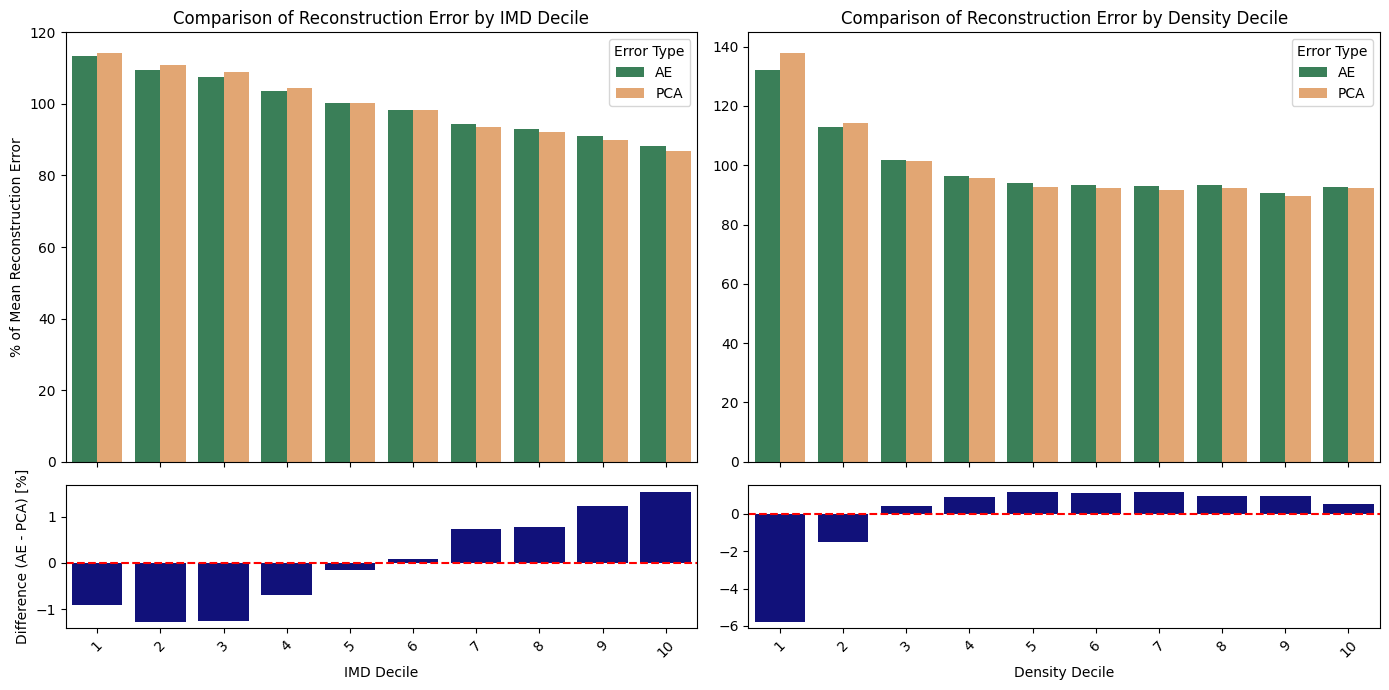

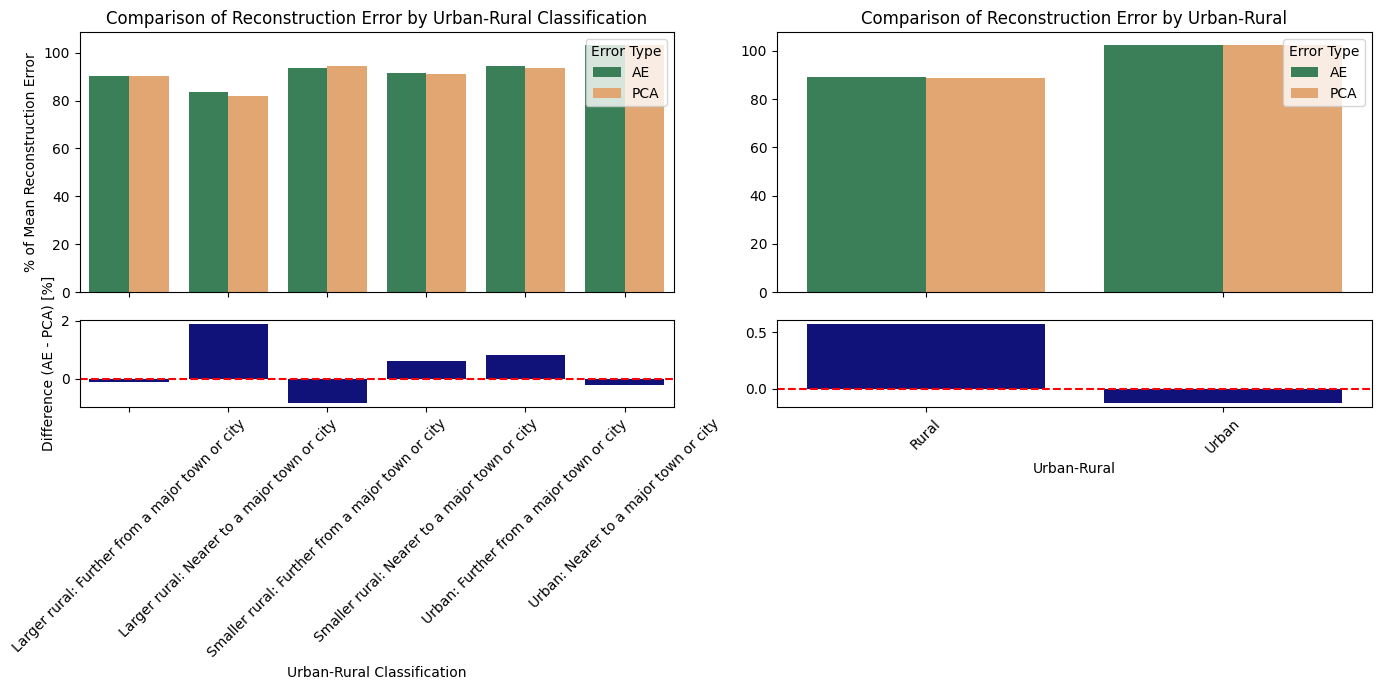

/tmp/ipykernel_340942/170293569.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels([fill(label, width=10) for label in grouped[group_col]])
/tmp/ipykernel_340942/170293569.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels([fill(label, width=10) for label in grouped[group_col]])


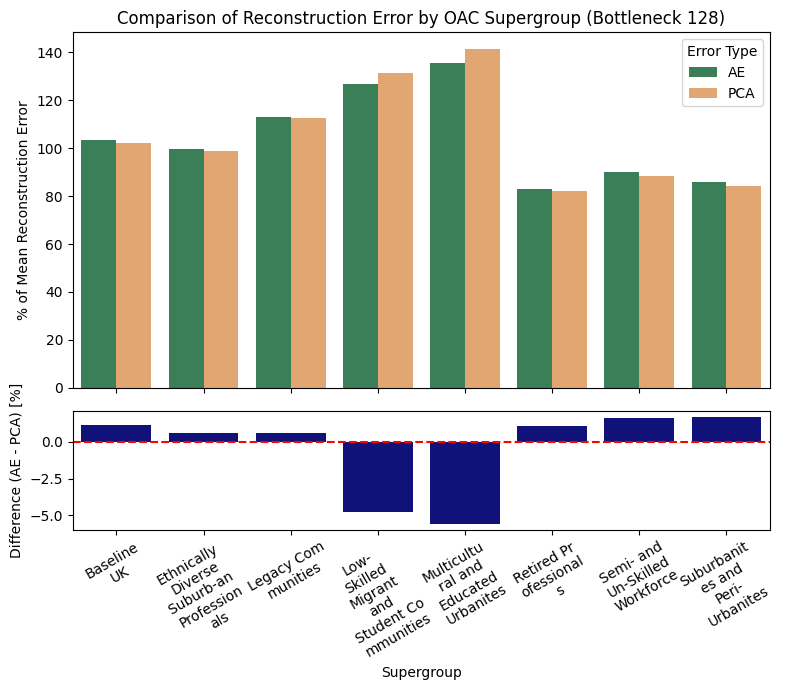

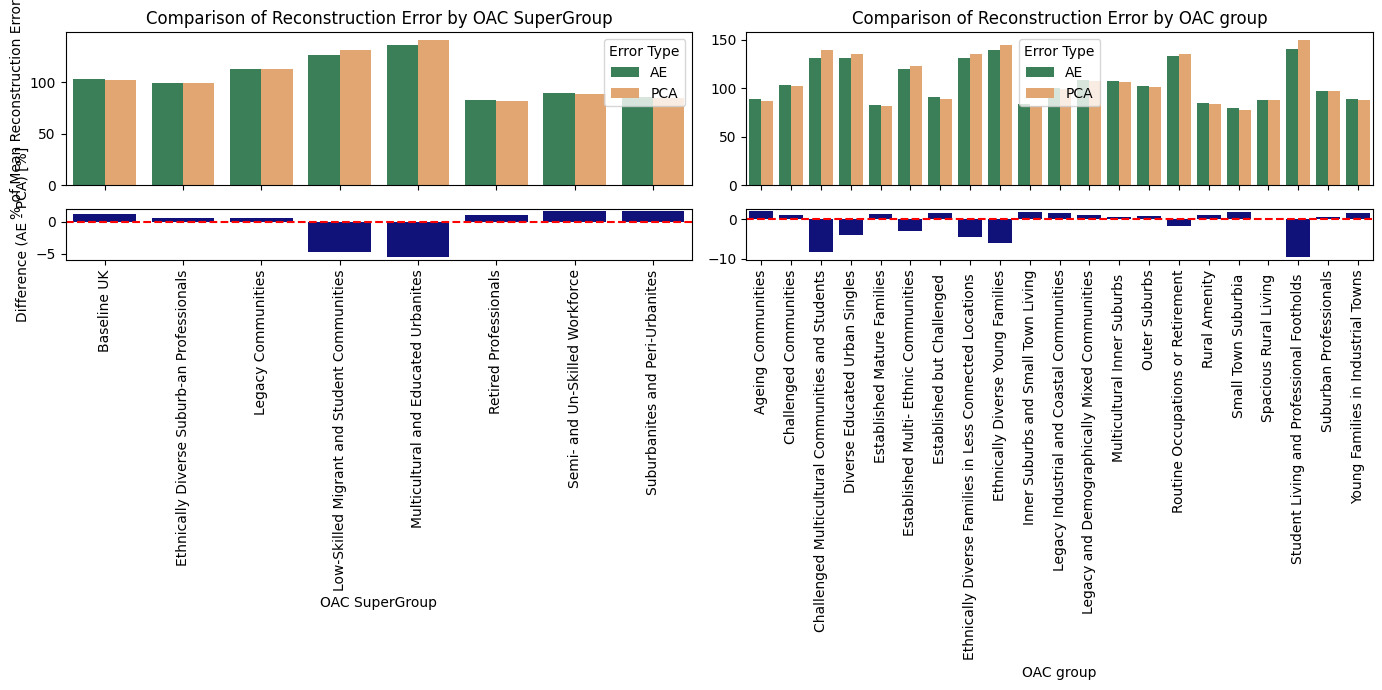

In [125]:
# Color palette
palette = {
    "AE": "seagreen",
    "PCA": "sandybrown"
}

for bottleneck in bottleneck_sizes:
    print(f"Processing bottleneck: {bottleneck}")
    #print line of hashes and big gap
    print("#" * 50)
    print("#" * 50)
    print("#" * 50)
    plot_side_by_side_charts(
        reco_err, 
        pca_reco_err, 
        "IMD", 
        "Density_decile", 
        "IMD Decile", 
        "Density Decile", 
        "Comparison of Reconstruction Error", 
        palette,
        bottleneck=bottleneck  
    )
    
    plot_side_by_side_charts(
        reco_err, 
        pca_reco_err, 
        "RUC21NM", 
        "Urban_rural_flag", 
        "Urban-Rural Classification", 
        "Urban-Rural", 
        "Comparison of Reconstruction Error", 
        palette,
        bottleneck=bottleneck  
    )

    # Keep the separate Supergroup plot
    plot_combined_chart(reco_err, pca_reco_err, "Supergroup_name", "Supergroup", "Comparison of Reconstruction Error by OAC Supergroup", palette, bottleneck=bottleneck, wrapped_labels=True)

    plot_side_by_side_charts(
        reco_err, 
        pca_reco_err, 
        "Supergroup_name", 
        "Group_name", 
        "OAC SuperGroup", 
        "OAC group", 
        "Comparison of Reconstruction Error", 
        palette,
        bottleneck=bottleneck, 
        rotation=90
    )



In [ ]:
# Load OA boundaries
oa_gdf = gpd.read_parquet("../data/geofiles/oabounds_2021approx.parquet")[["OA", "geometry"]].rename(columns={"OA": "OA21CD"})

# Merge while keeping suffixes on duplicates
merged = reco_err.merge(pca_reco_err, on="OA21CD", suffixes=("", "_pca"))
# Drop duplicated columns that came from pca_reco_err and already exist in reco_err
merged = merged[[col for col in merged.columns if not col.endswith("_pca") or col.startswith("pca_err")]]

# Merge with OA boundaries
merged = oa_gdf.merge(merged, on="OA21CD", how="right")

# Add computed columns
for b in bottleneck_sizes:
    merged[f"error_diff_ae_pca_{b}"] = merged[f"reco_err_{b}_norm"] - merged[f"pca_err_{b}_norm"]
    merged[f"AE_<_PCA_{b}"] = merged[f"reco_err_{b}_norm"] < merged[f"pca_err_{b}_norm"]


#set OA as index and round all columns to 5 dep
merged.set_index("OA21CD", inplace=True)
# Round all columns to 5 decimal places
merged = merged.round(5)
# Save to Parquet
merged.to_parquet("../data/outputs/maps/error_diff_by_OA.parquet")


In [ ]:


#load MSOA boundaries
msoa_gdf=gpd.read_file("../data/geofiles/Middle_layer_Super_Output_Areas_(December_2021)_Boundaries_EW_BFE_(V8)_and_RUC")[["MSOA21CD","geometry"]]

#drop all columns that are not reco_err or pca_err (only keep those that start with reco_err or pca_err)
merged = merged[[col for col in merged.columns if col.startswith("reco_err") or col.startswith("pca_err") or col == "MSOA21CD"]]
msoa = merged.groupby("MSOA21CD").mean().reset_index()
#techincally this is not correct as we are averaging after the normalization, but it is clos

# Add computed columns
for b in bottleneck_sizes:
    msoa[f"error_diff_ae_pca_{b}"] = msoa[f"reco_err_{b}_norm"] - msoa[f"pca_err_{b}_norm"]
    msoa[f"AE_<_PCA_{b}"] = msoa[f"reco_err_{b}_norm"] < msoa[f"pca_err_{b}_norm"]

#merge the MSOA boundaries
msoa = msoa_gdf.merge(msoa, on="MSOA21CD", how="right")

#save to parquet
msoa.to_parquet("../data/outputs/maps/error_diff_by_MSOA.parquet")
